In [1]:
from shapely.geometry import Polygon
from geopandas import GeoDataFrame
from geopandas import GeoSeries
import random
import numpy as np

/mnt/efs/h/Dropbox/MADLAB/Git_Repos/peter/gerrytools-dev/.venv/lib/python3.11/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


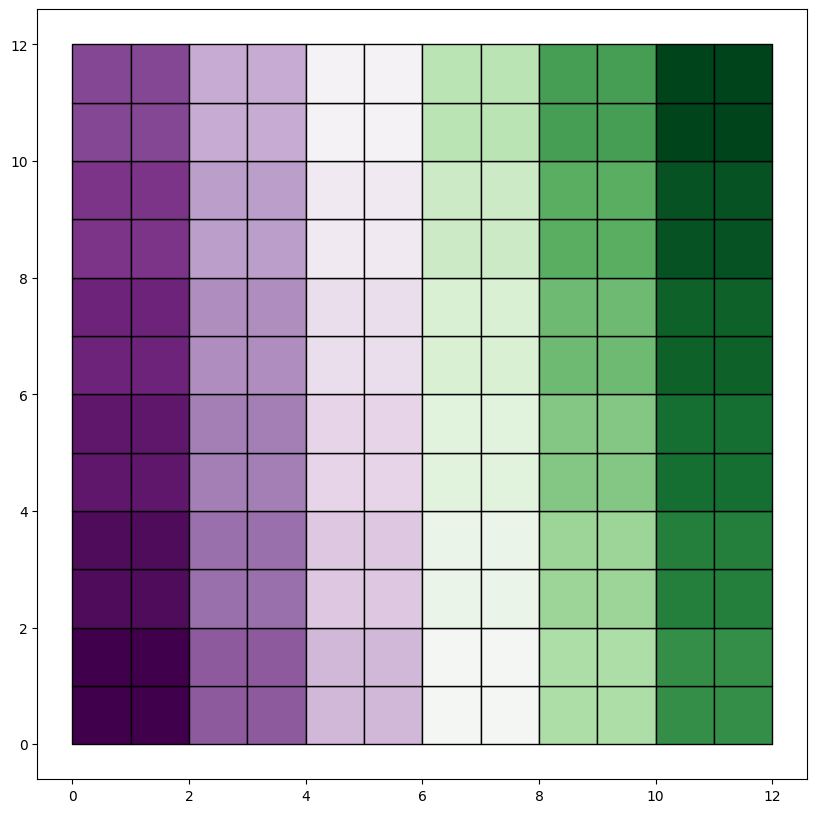

In [2]:
def create_rectangle(xmin, ymin, xmax, ymax):
    """Create a rectangle polygon from the given coordinates."""
    return Polygon([(xmin, ymin), (xmax, ymin), (xmax, ymax), (xmin, ymax)])


all_polygons = []
counties = []
vtds = []
assignments = []
square_size = 12
assignment_size = 2
for i in range(square_size):
    for j in range(square_size):
        all_polygons.append(create_rectangle(i, j, i+1, j+1))
        county = f"County_{i//4}_{j//4}"
        counties.append(county)
        vtds.append(f"VTD_{i}_{j}")
        assignment = (i // assignment_size) * (square_size // assignment_size) + (j // assignment_size)
        assignments.append(assignment)

maj_populations = np.array([random.randint(1000, 5000) for _ in range(len(all_polygons))])
min_populations = np.array([random.randint(wp // 4, int(wp * 1.1)) for wp in maj_populations])
total_populations = maj_populations + min_populations
gdf = GeoDataFrame({'county': counties, 'vtd': vtds, 'district': assignments, 'tot_pop': total_populations, "maj_pop": maj_populations, "min_pop": min_populations}, geometry=GeoSeries(all_polygons))
gdf.plot(column='district', edgecolor='black', cmap='PRGn', figsize=(10, 10))
gdf.to_file("testing_12x12.gpkg", layer='testing_12x12', driver="GPKG")


In [3]:
from gerrytools.plotting import DotDensityPlot

In [4]:
dir(DotDensityPlot)

['_DotDensityPlot__draw_interleaved_scatter_blocks',
 '__abstractmethods__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_apply_limits',
 '_build_and_apply_settings',
 '_build_plot',
 '_close',
 '_draw_all_dots',
 '_draw_deferred_labels',
 '_draw_legend',
 '_list_layers_in_draw_order',
 'add_dot_density',
 'add_highlight_layer',
 'add_label_layer',
 'add_marker_layer',
 'add_outline_layer',
 'ax',
 'clear_limits',
 'focus_axes',
 'get_label_positions',
 'rng_seed',
 'save',
 'save_legend',
 'set_legend_options',
 'set_marker_options',
 'set_xlim',
 'set_xlimits',
 'set_ylim',
 'set_ylimits',
 'show']

In [5]:
gdf

,county,vtd,district,tot_pop,maj_pop,min_pop,geometry
0,County_0_0,VTD_0_0,0,6453,3345,3108,"POLYGON ((0 0, 1 0, 1 1, 0 1, 0 0))"
1,County_0_0,VTD_0_1,0,5650,3682,1968,"POLYGON ((0 1, 1 1, 1 2, 0 2, 0 1))"
2,County_0_0,VTD_0_2,1,7775,4139,3636,"POLYGON ((0 2, 1 2, 1 3, 0 3, 0 2))"
3,County_0_0,VTD_0_3,1,2882,2274,608,"POLYGON ((0 3, 1 3, 1 4, 0 4, 0 3))"
4,County_0_1,VTD_0_4,2,8751,4394,4357,"POLYGON ((0 4, 1 4, 1 5, 0 5, 0 4))"
...,...,...,...,...,...,...,...
139,County_2_1,VTD_11_7,33,6847,4150,2697,"POLYGON ((11 7, 12 7, 12 8, 11 8, 11 7))"
140,County_2_2,VTD_11_8,34,6578,4822,1756,"POLYGON ((11 8, 12 8, 12 9, 11 9, 11 8))"
141,County_2_2,VTD_11_9,34,4615,2822,1793,"POLYGON ((11 9, 12 9, 12 10, 11 10, 11 9))"
142,County_2_2,VTD_11_10,35,6429,3613,2816,"POLYGON ((11 10, 12 10, 12 11, 11 11, 11 10))"


Generating dots for column 'maj_pop'.
Generating dots for column 'min_pop'.
Rendering 1 outline layer...
Rendering 1 highlight layer...
Rendering 7,169 dots for columns '['maj_pop', 'min_pop']'...


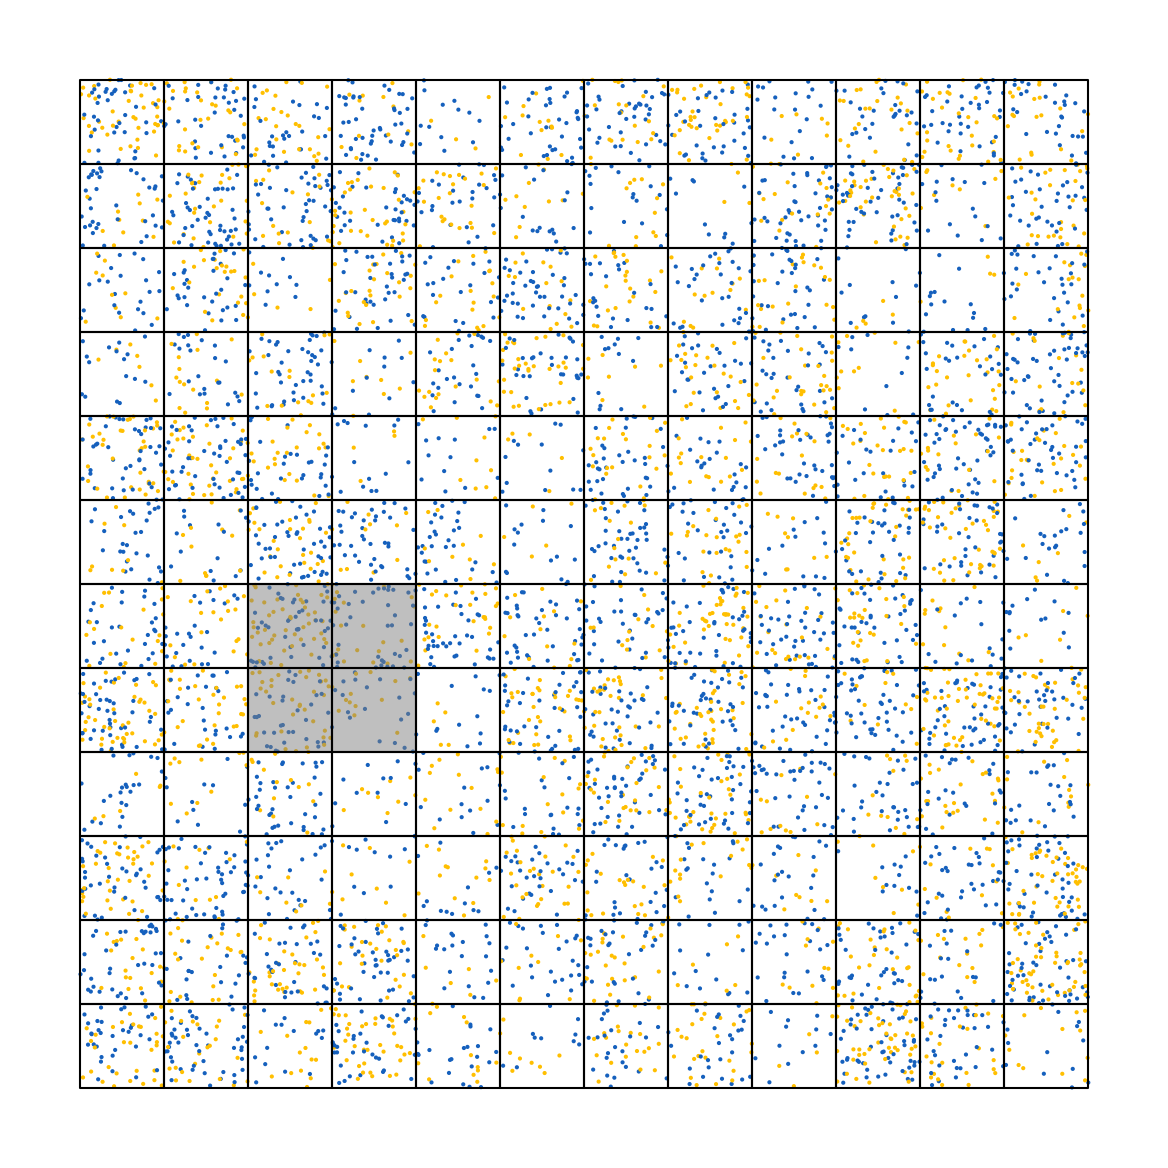

In [ ]:
dd_plot = DotDensityPlot(gdf, outline_column = "vtd", show_labels=False, edgewidth=0.5, rng_seed=43)

dd_plot.add_dot_density(column_name="maj_pop", color="denim")
dd_plot.add_dot_density(column_name="min_pop", color="amber")
dd_plot.add_highlight_layer(geometry_mask=gdf["district"] == 8)
dd_plot.show()